In [4]:
import zipfile
import glob
import yaml
import csv
import os

**Data Extraction and Transformation** (Extract YAML → CSV and create the master dataset)

In [5]:

# Extract ZIP
zip_path = "/content/Stock  data.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/yaml_files")

# Folder where all CSVs will be stored
csv_output_folder = "/content/csv_files"
os.makedirs(csv_output_folder, exist_ok=True)

# Find yaml files
yaml_files = glob.glob("/content/yaml_files/**/*.yaml", recursive=True)

print("Found YAML files:", len(yaml_files))

# Convert YAML -> CSV
for file in yaml_files:

    try:
        with open(file, "r", encoding="utf-8", errors="ignore") as f:
            data = yaml.safe_load(f)

        if isinstance(data, dict):
            data = [data]

        if not data:
            continue

        # CSV filename
        base_name = os.path.splitext(os.path.basename(file))[0]
        csv_file = os.path.join(csv_output_folder, base_name + ".csv")

        # Write CSV
        with open(csv_file, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=data[0].keys())

            writer.writeheader()
            writer.writerows(data)

        print(f"Saved: {csv_file}")

    except Exception as e:
        print(f"Error in {file}: {e}")

Found YAML files: 284
Saved: /content/csv_files/2024-02-06_05-30-00.csv
Saved: /content/csv_files/2024-02-08_05-30-00.csv
Saved: /content/csv_files/2024-02-22_05-30-00.csv
Saved: /content/csv_files/2024-02-05_05-30-00.csv
Saved: /content/csv_files/2024-02-19_05-30-00.csv
Saved: /content/csv_files/2024-02-14_05-30-00.csv
Saved: /content/csv_files/2024-02-20_05-30-00.csv
Saved: /content/csv_files/2024-02-13_05-30-00.csv
Saved: /content/csv_files/2024-02-12_05-30-00.csv
Saved: /content/csv_files/2024-02-09_05-30-00.csv
Saved: /content/csv_files/2024-02-28_05-30-00.csv
Saved: /content/csv_files/2024-02-23_05-30-00.csv
Saved: /content/csv_files/2024-02-01_05-30-00.csv
Saved: /content/csv_files/2024-02-27_05-30-00.csv
Saved: /content/csv_files/2024-02-16_05-30-00.csv
Saved: /content/csv_files/2024-02-29_05-30-00.csv
Saved: /content/csv_files/2024-02-07_05-30-00.csv
Saved: /content/csv_files/2024-02-02_05-30-00.csv
Saved: /content/csv_files/2024-02-26_05-30-00.csv
Saved: /content/csv_files/20

In [6]:
import shutil

# Create zip
shutil.make_archive(
    "/content/csv_files",
    'zip',
    "/content/csv_files"
)

print("ZIP created")

ZIP created


In [7]:
import pandas as pd
import glob

# Get all csv files
csv_files = glob.glob("/content/csv_files/*.csv")

# Store dataframes
df_list = []

for file in csv_files:
    try:
        df = pd.read_csv(file)

        # Append dataframe
        df_list.append(df)

    except Exception as e:
        print(f"Error in {file}: {e}")

# Combine all files
combined_df = pd.concat(df_list, ignore_index=True)

# Sort by ticker and date
combined_df = combined_df.sort_values(
    by=["Ticker", "date"]
)

# Save final file
output_file = "/content/combined_ticker_data.csv"

combined_df.to_csv(output_file, index=False)

print("Saved:", output_file)

# Preview
print(combined_df.head())

Saved: /content/combined_ticker_data.csv
         Ticker    close                 date     high      low    month  \
4574   ADANIENT  2387.25  2023-10-03 05:30:00  2424.90  2372.00  2023-10   
9474   ADANIENT  2464.95  2023-10-04 05:30:00  2502.75  2392.25  2023-10   
3374   ADANIENT  2466.35  2023-10-05 05:30:00  2486.50  2446.40  2023-10   
174    ADANIENT  2478.10  2023-10-06 05:30:00  2514.95  2466.05  2023-10   
10274  ADANIENT  2442.60  2023-10-09 05:30:00  2459.70  2411.30  2023-10   

          open   volume  
4574   2418.00  2019899  
9474   2402.20  2857377  
3374   2477.95  1132455  
174    2466.35  1510035  
10274  2440.00  1408224  


In [8]:
import pandas as pd
import os

# Read combined file
df = pd.read_csv("/content/combined_ticker_data.csv")

# Create output folder
output_folder = "/content/ticker_csvs"
os.makedirs(output_folder, exist_ok=True)

# Split by ticker
for ticker, group in df.groupby("Ticker"):

    # Clean filename
    ticker_name = str(ticker).replace("/", "_")

    # File path
    file_path = os.path.join(
        output_folder,
        f"{ticker_name}.csv"
    )

    # Save ticker data
    group.to_csv(file_path, index=False)

    print(f"Saved: {file_path}")

print("All ticker CSVs created")

Saved: /content/ticker_csvs/ADANIENT.csv
Saved: /content/ticker_csvs/ADANIPORTS.csv
Saved: /content/ticker_csvs/APOLLOHOSP.csv
Saved: /content/ticker_csvs/ASIANPAINT.csv
Saved: /content/ticker_csvs/AXISBANK.csv
Saved: /content/ticker_csvs/BAJAJ-AUTO.csv
Saved: /content/ticker_csvs/BAJAJFINSV.csv
Saved: /content/ticker_csvs/BAJFINANCE.csv
Saved: /content/ticker_csvs/BEL.csv
Saved: /content/ticker_csvs/BHARTIARTL.csv
Saved: /content/ticker_csvs/BPCL.csv
Saved: /content/ticker_csvs/BRITANNIA.csv
Saved: /content/ticker_csvs/CIPLA.csv
Saved: /content/ticker_csvs/COALINDIA.csv
Saved: /content/ticker_csvs/DRREDDY.csv
Saved: /content/ticker_csvs/EICHERMOT.csv
Saved: /content/ticker_csvs/GRASIM.csv
Saved: /content/ticker_csvs/HCLTECH.csv
Saved: /content/ticker_csvs/HDFCBANK.csv
Saved: /content/ticker_csvs/HDFCLIFE.csv
Saved: /content/ticker_csvs/HEROMOTOCO.csv
Saved: /content/ticker_csvs/HINDALCO.csv
Saved: /content/ticker_csvs/HINDUNILVR.csv
Saved: /content/ticker_csvs/ICICIBANK.csv
Saved: /co

In [9]:
import shutil

shutil.make_archive(
    "/content/ticker_csvs",
    'zip',
    "/content/ticker_csvs"
)

'/content/ticker_csvs.zip'

In [16]:
import zipfile

with zipfile.ZipFile("/content/ticker_csvs.zip", "r") as zip_ref:
    zip_ref.extractall("/content/stocks")

In [17]:
import os

files = os.listdir("/content/stocks")

print("Total files:", len(files))
print(files[:5])

Total files: 50
['MARUTI.csv', 'ONGC.csv', 'BHARTIARTL.csv', 'JSWSTEEL.csv', 'TATAMOTORS.csv']


Data cleaning - commbind ticker data all 50s

In [18]:
import pandas as pd
import os

all_data = []

for file in files:
    if file.endswith(".csv"):
        path = os.path.join("/content/stocks", file)
        df = pd.read_csv(path)

        # Add stock symbol
        df["Symbol"] = file.replace(".csv", "")

        all_data.append(df)

# Combine all dataframes
master_df = pd.concat(all_data, ignore_index=True)

print(master_df.shape)
master_df.head()

(14200, 9)


,Ticker,close,date,high,low,month,open,volume,Symbol
0,MARUTI,10346.9,2023-10-03 05:30:00,10709.8,10303.3,2023-10,10709.8,623006,MARUTI
1,MARUTI,10129.8,2023-10-04 05:30:00,10283.9,10090.0,2023-10,10283.9,407793,MARUTI
2,MARUTI,10210.2,2023-10-05 05:30:00,10271.0,10109.0,2023-10,10182.0,377196,MARUTI
3,MARUTI,10302.0,2023-10-06 05:30:00,10333.0,10260.0,2023-10,10283.0,335700,MARUTI
4,MARUTI,10244.8,2023-10-09 05:30:00,10334.4,10184.0,2023-10,10250.0,230083,MARUTI


In [20]:
master_df.columns

Index(['Ticker', 'close', 'date', 'high', 'low', 'month', 'open', 'volume',
       'Symbol'],
      dtype='object')

# missing value check

In [21]:
master_df.isnull().sum()

,0
Ticker,0
close,0
date,0
high,0
low,0
month,0
open,0
volume,0
Symbol,0


In [ ]:
# Duplicate value check

In [22]:
master_df.duplicated().sum()

np.int64(0)

In [ ]:
# Datatypes check-need to change month and date dtypes

In [23]:
master_df.dtypes

,0
Ticker,object
close,float64
date,object
high,float64
low,float64
month,object
open,float64
volume,int64
Symbol,object


In [25]:
print(master_df.columns.tolist())

['Ticker', 'close', 'date', 'high', 'low', 'month', 'open', 'volume', 'Symbol']


In [26]:
master_df.columns = master_df.columns.str.strip() # checking any whitespaces there
print(master_df.columns.tolist())

['Ticker', 'close', 'date', 'high', 'low', 'month', 'open', 'volume', 'Symbol']


In [27]:
(master_df["Ticker"] == master_df["Symbol"]).all() # comparing both columns

np.True_

In [28]:
print(master_df.columns.tolist())

['Ticker', 'close', 'date', 'high', 'low', 'month', 'open', 'volume', 'Symbol']


In [29]:
master_df["date"] = pd.to_datetime(master_df["date"]) # change date datatype

In [40]:
master_df["month"] = master_df["date"].dt.to_period("M") # change month datatype

In [30]:
master_df.isnull().sum()

,0
Ticker,0
close,0
date,0
high,0
low,0
month,0
open,0
volume,0
Symbol,0


In [31]:
master_df.duplicated().sum()

np.int64(0)

In [32]:
(master_df["close"] <= 0).sum()
(master_df["volume"] < 0).sum()

np.int64(0)

In [41]:
master_df.dtypes # checking datatypes changed or not

,0
Ticker,object
close,float64
date,datetime64[ns]
high,float64
low,float64
month,period[M]
open,float64
volume,int64
Symbol,object


In [39]:
master_df.head()

,Ticker,close,date,high,low,month,open,volume,Symbol
0,MARUTI,10346.9,2023-10-03 05:30:00,10709.8,10303.3,2023-10,10709.8,623006,MARUTI
1,MARUTI,10129.8,2023-10-04 05:30:00,10283.9,10090.0,2023-10,10283.9,407793,MARUTI
2,MARUTI,10210.2,2023-10-05 05:30:00,10271.0,10109.0,2023-10,10182.0,377196,MARUTI
3,MARUTI,10302.0,2023-10-06 05:30:00,10333.0,10260.0,2023-10,10283.0,335700,MARUTI
4,MARUTI,10244.8,2023-10-09 05:30:00,10334.4,10184.0,2023-10,10250.0,230083,MARUTI


**1. Volatility Analysis:**

In [4]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
with zipfile.ZipFile("/content/ticker_csvs.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/stocks")


files = os.listdir("/content/stocks")

         Stock  Volatility
0       MARUTI    0.013712
1         ONGC    0.022247
2   BHARTIARTL    0.013625
3     JSWSTEEL    0.016384
4   TATAMOTORS    0.017877
5     HDFCBANK    0.013490
6      HCLTECH    0.014295
7      DRREDDY    0.012490
8     ADANIENT    0.028601
9         INFY    0.014492
10  HINDUNILVR    0.012074
11        SBIN    0.017939
12      GRASIM    0.014465
13          LT    0.016964
14  INDUSINDBK    0.019111
15   EICHERMOT    0.016099
16  BAJAJ-AUTO    0.017609
17   BRITANNIA    0.013039
18        NTPC    0.019475
19  ULTRACEMCO    0.014315
20  BAJAJFINSV    0.014118
21  SHRIRAMFIN    0.021687
22        BPCL    0.022069
23  APOLLOHOSP    0.014135
24   TATASTEEL    0.018232
25   COALINDIA    0.021411
26   KOTAKBANK    0.014216
27     SBILIFE    0.015113
28       TRENT    0.023074
29         ITC    0.011944
30       TITAN    0.014136
31  HEROMOTOCO    0.016563
32  ASIANPAINT    0.012665
33  ADANIPORTS    0.026029
34       TECHM    0.016020
35    HDFCLIFE    0.014630
3

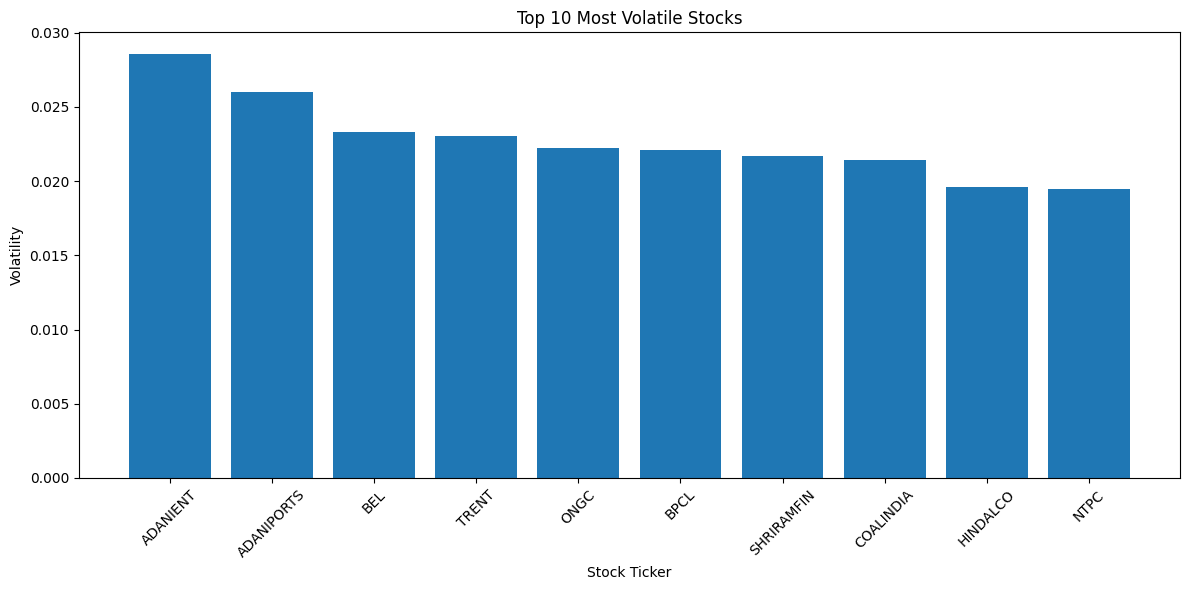

Top 10 volatility CSV saved successfully!


In [6]:
import pandas as pd
import zipfile
from pathlib import Path
with zipfile.ZipFile("/content/ticker_csvs.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/stocks")
extract_dir = "/content/stocks"


volatility_data = {}


for file in Path(extract_dir).glob("*.csv"):


    df = pd.read_csv(file)

    df.columns = df.columns.str.strip()

    df.columns = df.columns.str.lower()

    if "close" in df.columns:

        df = df.dropna(subset=["close"])

        df["daily_return"] = df["close"].pct_change()

        volatility = df["daily_return"].std()

        if pd.notna(volatility):

            stock_name = file.stem

            volatility_data[stock_name] = volatility

vol_df = pd.DataFrame(
    list(volatility_data.items()),
    columns=["Stock", "Volatility"]
)

print(vol_df)

top10 = vol_df.sort_values(
    by="Volatility",
    ascending=False
).head(10)

print(top10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["Stock"],
    top10["Volatility"]
)

plt.xlabel("Stock Ticker")
plt.ylabel("Volatility")
plt.title("Top 10 Most Volatile Stocks")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

top10.to_csv("/content/top10_volatile_stocks.csv", index=False)

print("Top 10 volatility CSV saved successfully!")

Intrepretation:
Adanient is the topper volatile stocks out of top 10 stocks whereas ntpc is 10th place stocks

**2. Cumulative Return Over Time**

Top 5 Stocks:
['TRENT', 'BEL', 'M&M', 'BAJAJ-AUTO', 'BHARTIARTL']


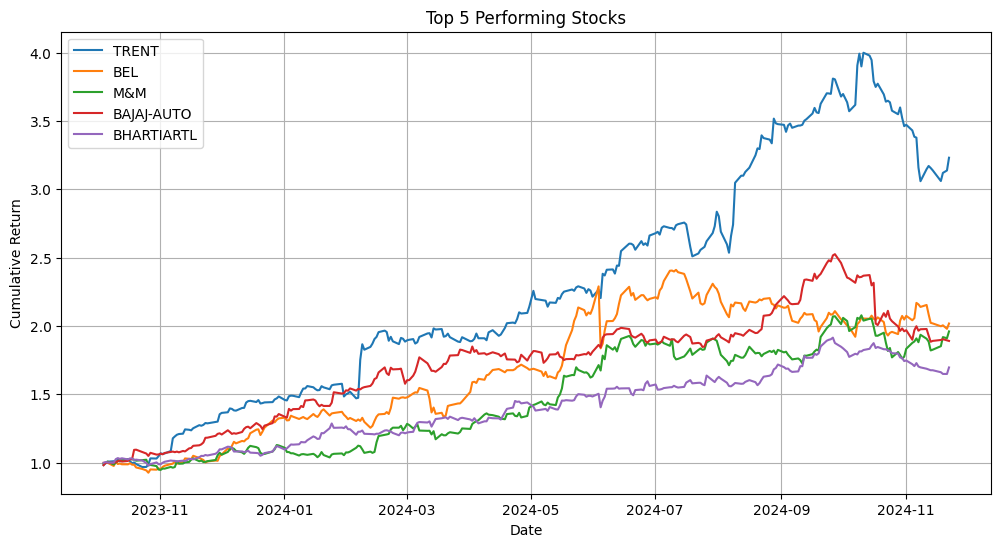

CSV file saved successfully!


In [45]:
import os
import pandas as pd
import matplotlib.pyplot as plt

files = os.listdir("/content/stocks")

final_returns = {}

for file in files:

    path = os.path.join("/content/stocks", file)

    df = pd.read_csv(path)
    if 'Date' in df.columns:
        date_col = 'Date'

    elif 'date' in df.columns:
        date_col = 'date'

    elif 'timestamp' in df.columns:
        date_col = 'timestamp'

    else:
        continue


    if 'Close' in df.columns:
        price_col = 'Close'

    elif 'Adj Close' in df.columns:
        price_col = 'Adj Close'

    elif 'close' in df.columns:
        price_col = 'close'

    else:
        continue

    df[date_col] = pd.to_datetime(df[date_col])

    df = df.sort_values(date_col)

    df['Daily Return'] = df[price_col].pct_change()

    df['Cumulative Return'] = (1 + df['Daily Return']).cumprod()

    final_value = df['Cumulative Return'].iloc[-1]

    stock = file.replace(".csv", "")

    final_returns[stock] = final_value

top5 = sorted(
    final_returns,
    key=final_returns.get,
    reverse=True
)[:5]

print("Top 5 Stocks:")
print(top5)

plt.figure(figsize=(12,6))

for stock in top5:

    path = f"/content/stocks/{stock}.csv"

    df = pd.read_csv(path)

    if 'Date' in df.columns:
        date_col = 'Date'

    elif 'date' in df.columns:
        date_col = 'date'

    else:
        date_col = 'timestamp'

    if 'Close' in df.columns:
       price_col = 'Close'

    elif 'Adj Close' in df.columns:
        price_col = 'Adj Close'

    else:
        price_col = 'close'

    df[date_col] = pd.to_datetime(df[date_col])


    df = df.sort_values(date_col)


    df['Daily Return'] = df[price_col].pct_change()


    df['Cumulative Return'] = (1 + df['Daily Return']).cumprod()

    plt.plot(
        df[date_col],
        df['Cumulative Return'],
        label=stock
    )


plt.title("Top 5 Performing Stocks")

plt.xlabel("Date")

plt.ylabel("Cumulative Return")

plt.legend()
plt.grid(True)

plt.show()

top5_df = pd.DataFrame({
    'Stock': top5,
    'Final Return': [final_returns[stock] for stock in top5]
})


top5_df.to_csv("top5_stocks.csv", index=False)

print("CSV file saved successfully!")

Interpretation:

Trent is the top stock performer monthlywise on top 5
bhartiartl shows the least performer on top 5

**4. Stock Price Correlation**

    MARUTI    ONGC  BHARTIARTL  JSWSTEEL  TATAMOTORS  HDFCBANK  HCLTECH  \
0  10346.9  184.60      925.30    770.25      620.45   1508.05  1238.70   
1  10129.8  182.75      924.25    756.60      613.60   1529.55  1239.55   
2  10210.2  182.20      928.85    755.50      619.60   1535.75  1235.45   
3  10302.0  181.45      926.05    765.20      622.45   1534.05  1237.70   
4  10244.8  181.70      924.55    757.55      617.35   1516.25  1249.60   

   DRREDDY  ADANIENT     INFY  ...     BEL  SUNPHARMA  HINDALCO      M&M  \
0  1092.34   2387.25  1434.00  ...  139.20    1141.45    479.95  1537.40   
1  1083.56   2464.95  1444.35  ...  138.85    1123.80    473.40  1522.10   
2  1081.45   2466.35  1463.45  ...  138.95    1119.10    470.55  1537.95   
3  1084.98   2478.10  1478.70  ...  139.00    1127.30    472.60  1548.85   
4  1098.97   2442.60  1475.45  ...  135.75    1123.05    469.80  1515.20   

   POWERGRID    CIPLA  BAJFINANCE  AXISBANK  RELIANCE      TCS  
0     199.55  1182.80     7

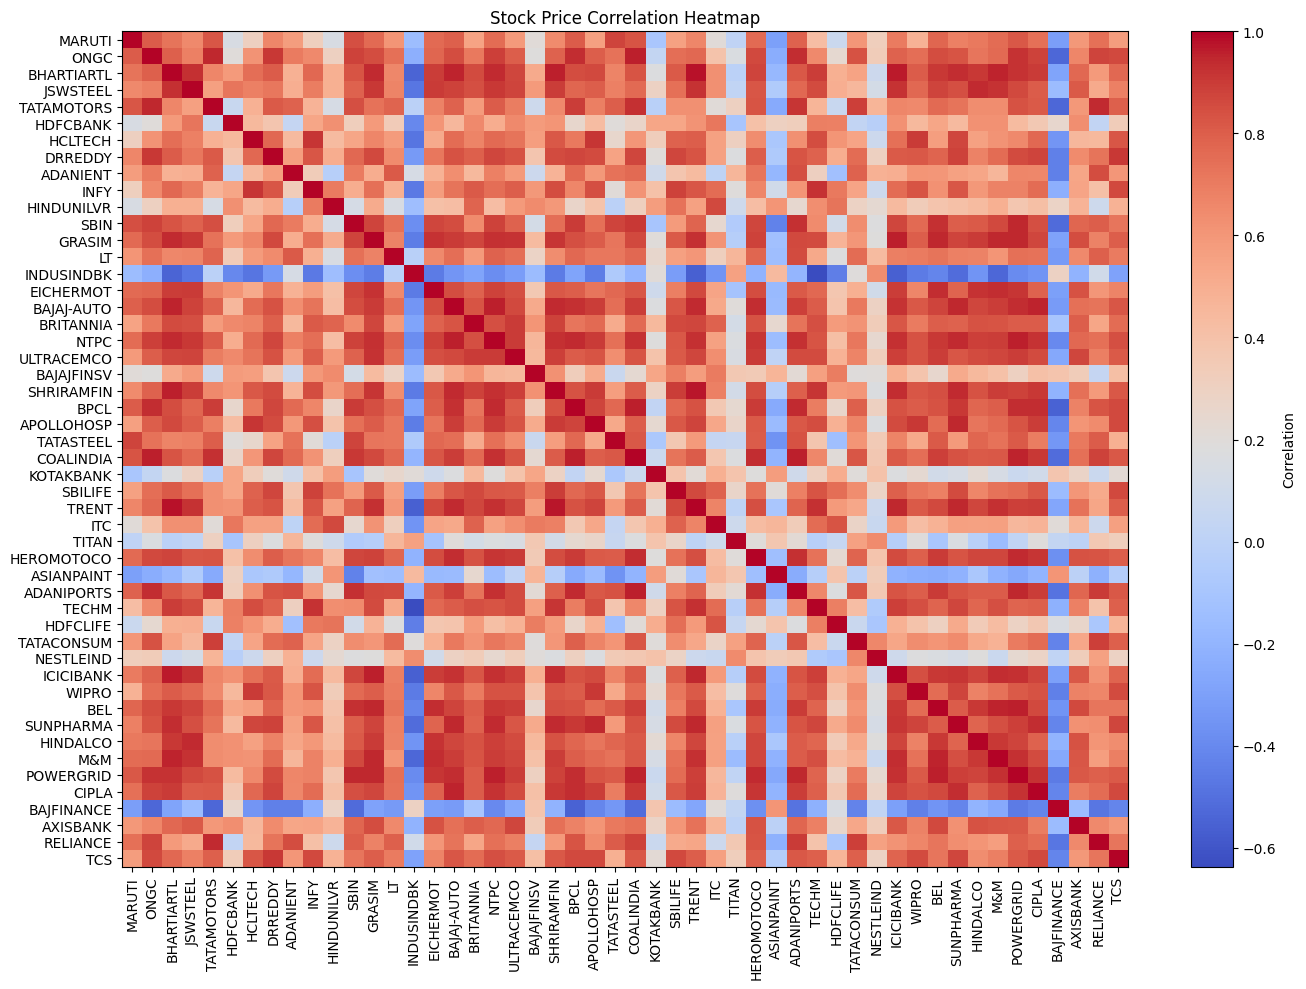

Correlation matrix saved successfully!


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
from pathlib import Path



with zipfile.ZipFile("/content/ticker_csvs.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/stocks")

extract_dir = "/content/stocks"

all_stocks = pd.DataFrame()

for file in Path(extract_dir).glob("*.csv"):

    df = pd.read_csv(file)

    df.columns = df.columns.str.strip().str.lower()

    if "close" in df.columns:

        df = df.dropna(subset=["close"])

        stock_name = file.stem.upper()

        all_stocks[stock_name] = df["close"]


print(all_stocks.head())

correlation_matrix = all_stocks.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)


plt.figure(figsize=(14,10))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Stock Price Correlation Heatmap")

plt.tight_layout()

plt.show()

correlation_matrix.to_csv(
    "stock_correlation_matrix.csv"
)

print("Correlation matrix saved successfully!")

Intrepretation:

50 stocks correlation was created
Bajajfinsev shows positive correlation 1.0

**5. Top 5 Gainers and Losers (Month-wise)**

    stock     month  monthly_return
0  MARUTI     April        1.972219
1  MARUTI    August       -7.156572
2  MARUTI  December       -2.677197
3  MARUTI  February        6.113461
4  MARUTI   January       -0.937442


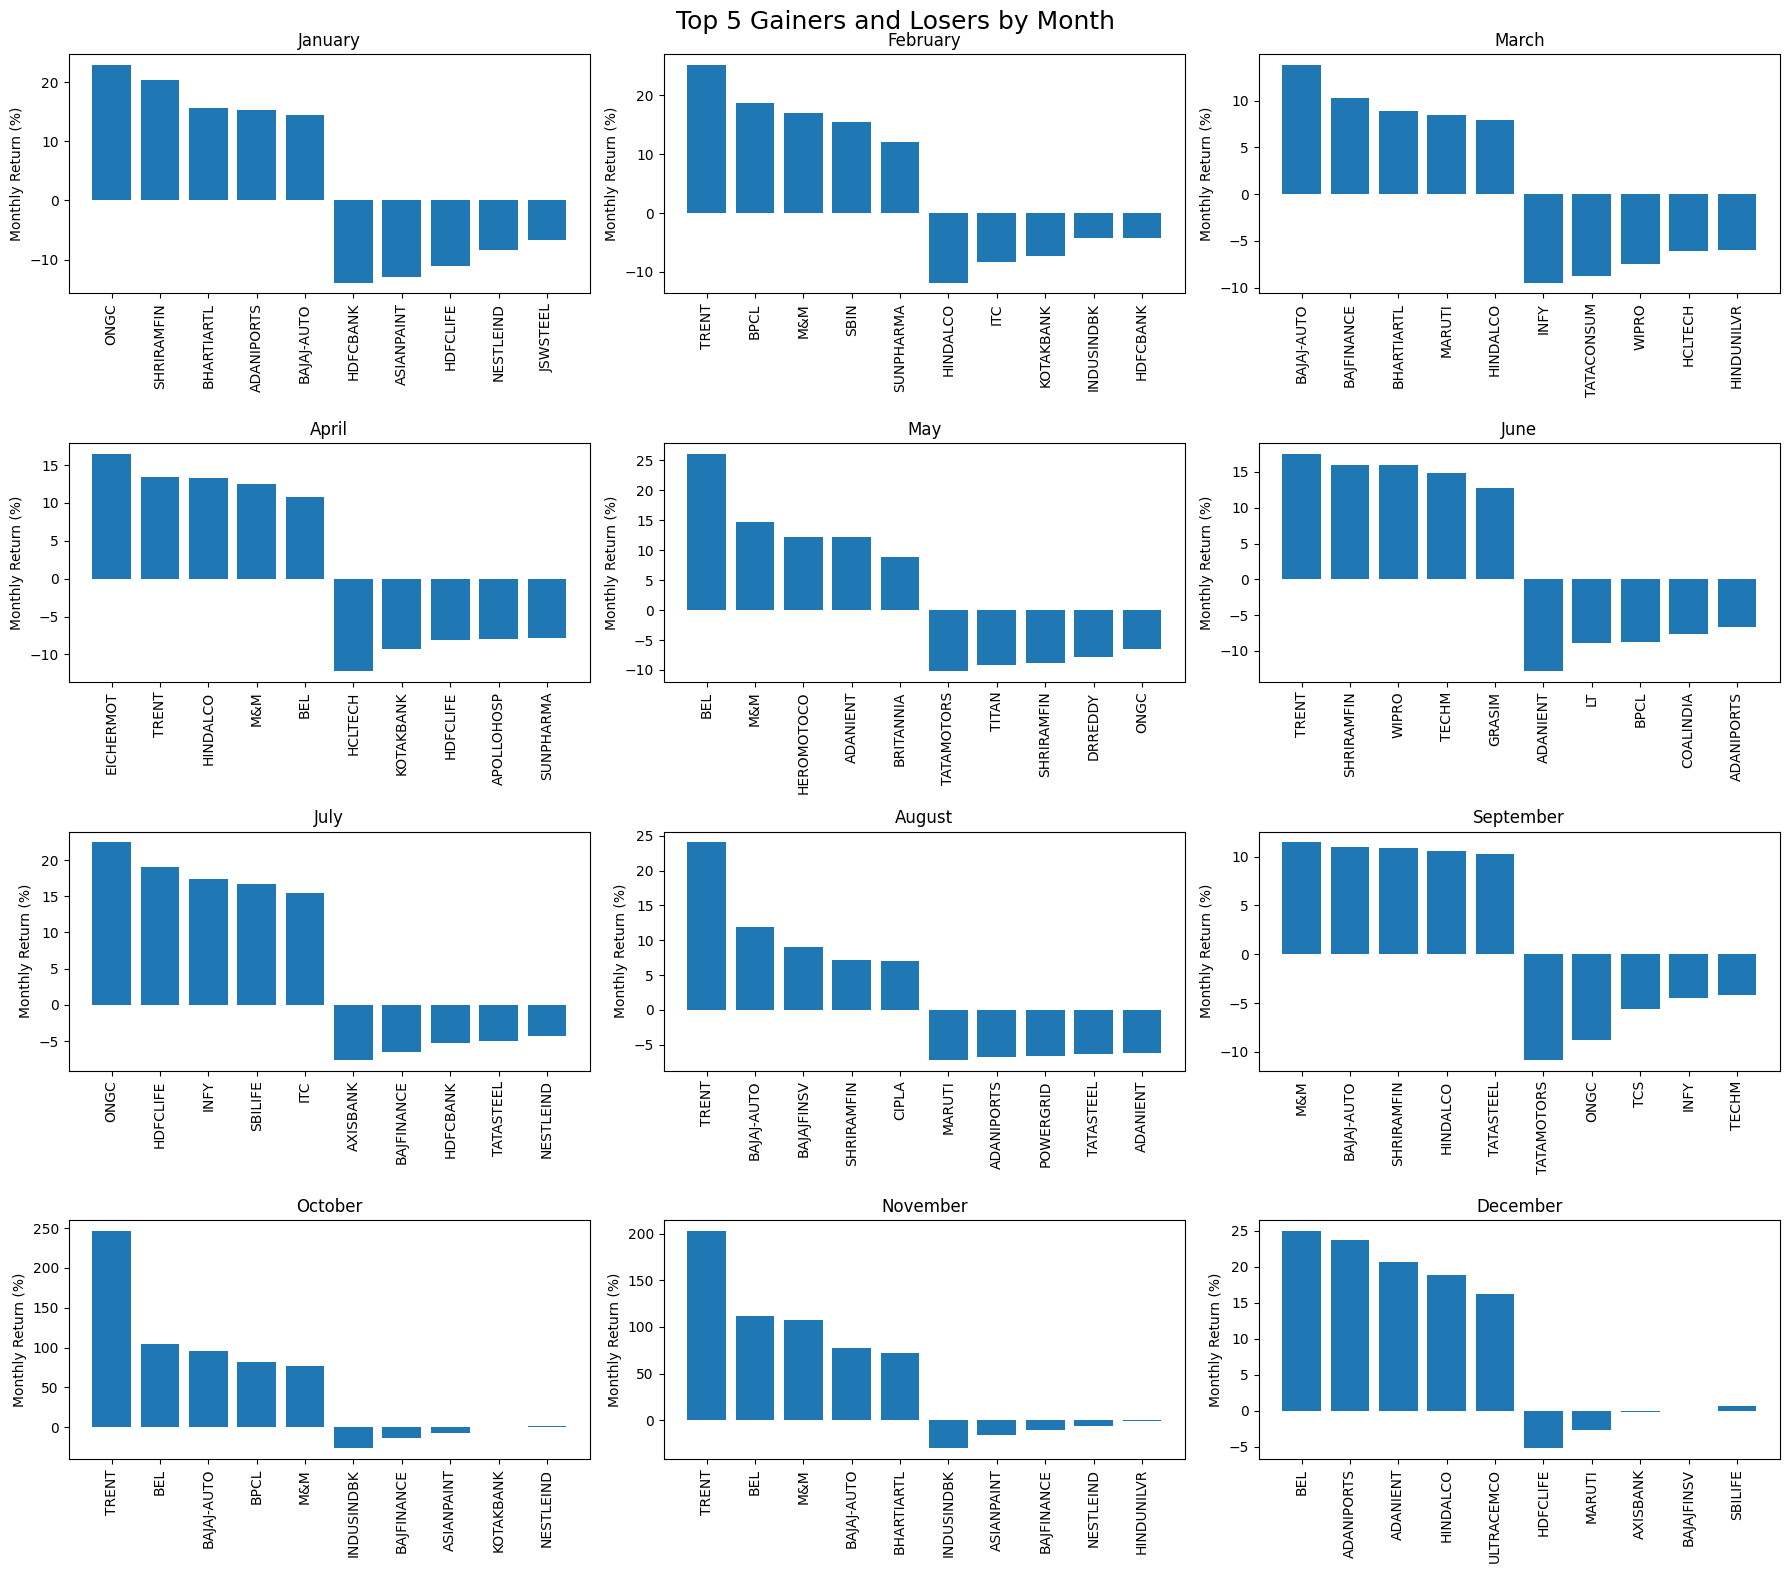

Monthly returns CSV saved successfully!


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
from pathlib import Path

with zipfile.ZipFile("/content/ticker_csvs.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/stocks")

extract_dir = "/content/stocks"

monthly_returns = []

for file in Path(extract_dir).glob("*.csv"):

    df = pd.read_csv(file)

    df.columns = df.columns.str.strip().str.lower()

    if "date" in df.columns and "close" in df.columns:

        df["date"] = pd.to_datetime(df["date"])

        df = df.dropna(subset=["close"])

        df["month"] = df["date"].dt.month_name()

        monthly_group = df.groupby("month")

        for month, data in monthly_group:

            if len(data) > 1:

                first_price = data["close"].iloc[0]

                last_price = data["close"].iloc[-1]

                monthly_return = (
                    (last_price - first_price)
                    / first_price
                ) * 100


                monthly_returns.append({
                    "stock": file.stem.upper(),
                    "month": month,
                    "monthly_return": monthly_return
                })



monthly_df = pd.DataFrame(monthly_returns)

print(monthly_df.head())



month_order = [
    "January", "February", "March",
    "April", "May", "June",
    "July", "August", "September",
    "October", "November", "December"
]



fig, axes = plt.subplots(
    4, 3,
    figsize=(18,16)
)

axes = axes.flatten()

for i, month in enumerate(month_order):

    month_data = monthly_df[
        monthly_df["month"] == month
    ]

    if len(month_data) == 0:
        continue

    top_gainers = month_data.sort_values(
        by="monthly_return",
        ascending=False
    ).head(5)

    top_losers = month_data.sort_values(
        by="monthly_return",
        ascending=True
    ).head(5)

    combined = pd.concat([
        top_gainers,
        top_losers
    ])

    axes[i].bar(
        combined["stock"],
        combined["monthly_return"]
    )


    axes[i].set_title(month)

    axes[i].tick_params(
        axis='x',
        rotation=90
    )

    axes[i].set_ylabel(
        "Monthly Return (%)"
    )


fig.suptitle(
    "Top 5 Gainers and Losers by Month",
    fontsize=18
)


plt.tight_layout()

plt.show()


monthly_df.to_csv(
    "monthly_stock_returns.csv",
    index=False
)

print("Monthly returns CSV saved successfully!")



Interpretation:

In septemper month top 5 gainers monthly returns are shows similar
Top 5 Loss of october, november and december month was gradually decreased compare to other months.


**3. Sector-wise Performance-Data cleaning**

In [7]:
sector_df = pd.read_csv("/content/Sector_data - Sheet1.csv")

sector_df.head()

,COMPANY,sector,Symbol
0,ADANI ENTERPRISES,MISCELLANEOUS,ADANI ENTERPRISES: ADANIGREEN
1,ADANI PORTS & SEZ,MISCELLANEOUS,ADANI PORTS & SEZ: ADANIPORTS
2,APOLLO HOSPITALS,MISCELLANEOUS,APOLLO HOSPITALS: APOLLOHOSP
3,ASIAN PAINTS,PAINTS,ASIAN PAINTS: ASIANPAINT
4,AXIS BANK,BANKING,AXIS BANK: AXISBANK


In [8]:
sector_df.duplicated().sum()

np.int64(0)

In [9]:
sector_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   COMPANY  50 non-null     object
 1   sector   50 non-null     object
 2   Symbol   50 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB


In [10]:
sector_df.columns = sector_df.columns.str.strip().str.lower()

In [11]:
print(sector_df.columns)

Index(['company', 'sector', 'symbol'], dtype='object')


In [12]:

sector_df = df.columns.str.strip().str.lower()

**Sector Performance**

ZIP Extracted Successfully!

Sector Data Loaded!
             COMPANY         sector                         Symbol
0  ADANI ENTERPRISES  MISCELLANEOUS  ADANI ENTERPRISES: ADANIGREEN
1  ADANI PORTS & SEZ  MISCELLANEOUS  ADANI PORTS & SEZ: ADANIPORTS
2   APOLLO HOSPITALS  MISCELLANEOUS   APOLLO HOSPITALS: APOLLOHOSP
3       ASIAN PAINTS         PAINTS       ASIAN PAINTS: ASIANPAINT
4          AXIS BANK        BANKING            AXIS BANK: AXISBANK

Sector CSV Columns:
Index(['company', 'sector', 'symbol'], dtype='object')

Using Symbol Column: company
Using Sector Column: sector

Sector Mapping Created Successfully!

Final Data:
   Symbol     Sector  Yearly_Return
0    ONGC     ENERGY      33.044420
1  GRASIM   TEXTILES      35.781988
2    NTPC      POWER      51.513267
3    BPCL     ENERGY      67.477150
4   TRENT  RETAILING     223.092613

Final DataFrame Shape:
(12, 3)

Average Yearly Return by Sector:
Sector
RETAILING          113.305399
AUTOMOBILES         95.976974
POWER          

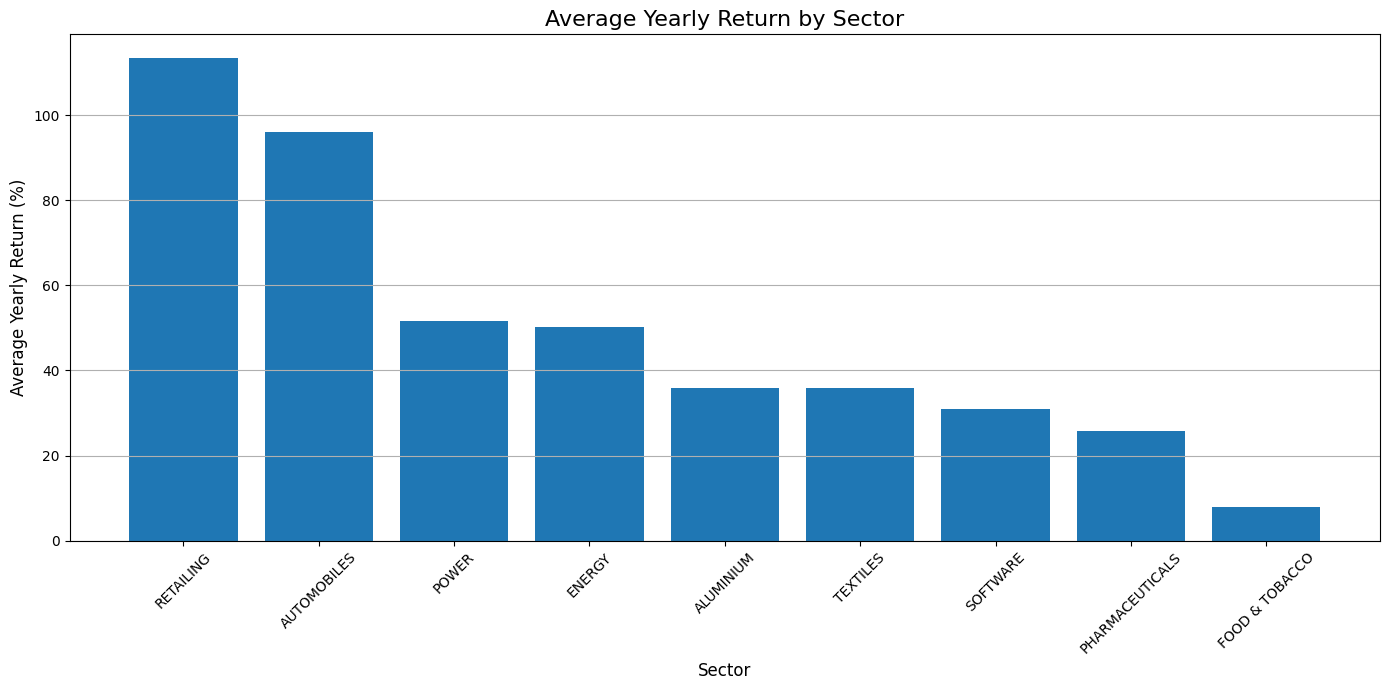


Sector Performance Saved Successfully!
Saved File: /content/sector_performance.csv


In [14]:


import pandas as pd
import numpy as np
import os
import zipfile
import matplotlib.pyplot as plt

zip_path = "/content/ticker_csvs.zip"

sector_file = "/content/Sector_data - Sheet1.csv"

extract_folder = "/content/ticker_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP Extracted Successfully!")

sector_df = pd.read_csv(sector_file)

print("\nSector Data Loaded!")
print(sector_df.head())

sector_df.columns = sector_df.columns.str.strip().str.lower()

print("\nSector CSV Columns:")
print(sector_df.columns)

symbol_col = sector_df.columns[0]
sector_col = sector_df.columns[1]

print(f"\nUsing Symbol Column: {symbol_col}")
print(f"Using Sector Column: {sector_col}")

sector_mapping = dict(
    zip(
        sector_df[symbol_col].astype(str).str.upper(),
        sector_df[sector_col]
    )
)
print("\nSector Mapping Created Successfully!")
results = []


for file in os.listdir(extract_folder):
    if file.endswith(".csv"):
        try:

            file_path = os.path.join(extract_folder, file)
            stock_df = pd.read_csv(file_path)

            stock_df.columns = (
                stock_df.columns
                .str.strip()
                .str.lower()
            )

            if 'close' not in stock_df.columns:
                print(f"'close' column missing in {file}")
                continue

            stock_df = stock_df.dropna(subset=['close'])

            if len(stock_df) < 2:
                continue

            ticker = file.replace(".csv", "").upper()

            first_price = stock_df['close'].iloc[0]

            last_price = stock_df['close'].iloc[-1]

            yearly_return = (
                (last_price - first_price)
                / first_price
            ) * 100

            sector = sector_mapping.get(ticker)


            if sector is None:
                continue

            results.append({
                'Symbol': ticker,
                'Sector': sector,
                'Yearly_Return': yearly_return
            })

        except Exception as e:
            print(f"Error in {file}: {e}")

final_df = pd.DataFrame(results)

print("\nFinal Data:")
print(final_df.head())

print("\nFinal DataFrame Shape:")
print(final_df.shape)

if final_df.empty:
    print("\nNo matching stock data found!")
else:
    sector_performance = (
        final_df
        .groupby('Sector')['Yearly_Return']
        .mean()
        .sort_values(ascending=False)
    )

    print("\nAverage Yearly Return by Sector:")
    print(sector_performance)

    sector_performance_df = (
        sector_performance
        .reset_index()
    )

    sector_performance_df.columns = [
        'Sector',
        'Average_Yearly_Return'
    ]

    print("\nSector Performance DataFrame:")
    print(sector_performance_df)

    plt.figure(figsize=(14,7))

    plt.bar(
        sector_performance_df['Sector'],
        sector_performance_df['Average_Yearly_Return']
    )

    plt.title(
        "Average Yearly Return by Sector",
        fontsize=16
    )

    plt.xlabel("Sector", fontsize=12)

    plt.ylabel(
        "Average Yearly Return (%)",
        fontsize=12
    )

    plt.xticks(rotation=45)

    plt.grid(axis='y')

    plt.tight_layout()

    plt.show()


    output_file = "/content/sector_performance.csv"

    sector_performance_df.to_csv(
        output_file,
        index=False
    )

    print("\nSector Performance Saved Successfully!")
    print(f"Saved File: {output_file}")


Interpretation:

Average yearly return retailing sector shows top whereas food & tobacco shows least